1. Mean, Median and Mode in the Context of Customer Income
Mean

Mean is the average value of all income observations.

Formula:

Mean = ΣX / N

Where:

X = Income values
N = Number of observations

Example:

Income = 30000, 40000, 50000, 50000, 70000

Mean = (30000 + 40000 + 50000 + 50000 + 70000) / 5

Mean = 48000

Median

Median is the middle value when data is arranged in ascending order.

Income = 30000, 40000, 50000, 50000, 70000

Median = 50000

Mode

Mode is the value occurring most frequently.

Mode = 50000

Importance

These measures summarize customer income distribution and help assess repayment capacity.

2. Difference Between Variance and Standard Deviation
Variance

Variance measures how far data points spread from the mean.

Formula:

Variance = Σ(x − μ)² / N

Where:

x = observation
μ = mean
N = total observations
Standard Deviation

Standard deviation is the square root of variance.

Formula:

Standard Deviation = √Variance

Comparison
Variance	Standard Deviation
Measured in squared units	Measured in original units
Difficult to interpret	Easy to interpret
Used in calculations	Used in reporting
Example

If loan amounts vary significantly among customers, variance and standard deviation will be high.

3. Random Variable

A random variable is a numerical quantity whose value depends on chance.

Examples:

Credit Score
Income
Loan Amount

A customer may have different values for these variables, making them random variables.

Types:

Discrete Random Variable
Continuous Random Variable

Income and Credit Score are examples of continuous random variables.

4. Conditional Probability

Conditional probability measures the likelihood of an event occurring given that another event has already occurred.

Formula:

P(A|B) = P(A ∩ B) / P(B)

Example:

P(Default | Credit Score < 600)

Meaning:

Probability that a customer defaults given that the customer's credit score is below 600.

Banks use conditional probability to evaluate risk before approving loans.

5. Bayes Theorem and Banking Applications

Bayes Theorem updates probabilities when new information becomes available.

Formula:

P(A|B) = [P(B|A) × P(A)] / P(B)

Applications:

Loan Approval
Credit Risk Analysis
Fraud Detection
Customer Segmentation
Insurance Risk Assessment

Bayes theorem helps banks estimate the probability of loan default using customer information.

6. Empirical Probability vs Theoretical Probability
Empirical Probability

Based on observed data.

Formula:

P(E) = Observed Events / Total Events

Example:

50 defaults among 500 loans

P(Default) = 50 / 500 = 0.10

Theoretical Probability

Based on mathematical assumptions.

Formula:

P(E) = Favorable Outcomes / Total Outcomes

Example:

Probability of obtaining Head on a fair coin toss

P(Head) = 1 / 2

Comparison

Empirical Probability:

Based on actual observations
Changes with new data

Theoretical Probability:

Based on assumptions
Fixed mathematically
7. Poisson Distribution

Poisson Distribution models the number of events occurring within a fixed interval.

Formula:

P(X=x) = (e^−λ × λ^x) / x!

Where:

λ = average number of events
x = actual number of events

Example:

A bank receives an average of 10 loan applications per hour. Poisson distribution can estimate the probability of receiving exactly 15 applications in the next hour.

Applications:

Loan Requests
Customer Arrivals
Insurance Claims
Fraud Detection
8. Eigenvalues and Eigenvectors in Data Analysis

Eigenvalues and Eigenvectors describe important directions and magnitudes in multidimensional data.

Formula:

Av = λv

7. Poisson Distribution

Poisson Distribution models the number of events occurring within a fixed interval.

Formula:

P(X=x) = (e^−λ × λ^x) / x!

Where:

λ = average number of events
x = actual number of events

8. Eigenvalues and Eigenvectors in Data Analysis

Eigenvalues and Eigenvectors describe important directions and magnitudes in multidimensional data.

Formula:

Av = λv

Where:

A = Matrix
v = Eigenvector
λ = Eigenvalue

Applications:

Principal Component Analysis (PCA)
Machine Learning
Data Compression
Recommendation Systems
Image Processing

Benefits:

Reduces dimensionality
Removes redundant information
Improves computational efficiency

PART B – PRACTICAL IMPLEMENTATION

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [18]:
df = pd.read_csv("loan_applications_5000_rows.csv")

print(df.head())
print(df.shape)
print(df.info())

  Customer_ID  Age  Income  Loan_Amount  Credit_Score  Loan_Term  \
0   CUST00001   59   57842       127658           775         48   
1   CUST00002   49   33900       215912           386         60   
2   CUST00003   35  147992       343151           367         12   
3   CUST00004   63  100059       156833           341         12   
4   CUST00005   28   21881       168637           356         36   

  Default_Status  
0             No  
1            Yes  
2             No  
3             No  
4            Yes  
(5000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer_ID     5000 non-null   object
 1   Age             5000 non-null   int64 
 2   Income          5000 non-null   int64 
 3   Loan_Amount     5000 non-null   int64 
 4   Credit_Score    5000 non-null   int64 
 5   Loan_Term       5000 non-null   int64 
 6   Defa

In [19]:
print(df.isnull().sum())

Customer_ID       0
Age               0
Income            0
Loan_Amount       0
Credit_Score      0
Loan_Term         0
Default_Status    0
dtype: int64


In [20]:
print("Mean Income:", df["Income"].mean())

print("Median Income:", df["Income"].median())

print("Mode Income:")
print(df["Income"].mode())

Mean Income: 84769.7798
Median Income: 85737.0
Mode Income:
0    122828
Name: Income, dtype: int64


In [21]:
loan_range = (
    df["Loan_Amount"].max()
    -
    df["Loan_Amount"].min()
)

print("Range:", loan_range)

print("Variance:",
      df["Loan_Amount"].var())

print("Standard Deviation:",
      df["Loan_Amount"].std())

Range: 449696
Variance: 16506715666.328825
Standard Deviation: 128478.46382304245


In [22]:
prob_default = (
    df["Default_Status"]
    .eq("Yes")
    .mean()
)

print(
    "Probability of Default:",
    prob_default
)

Probability of Default: 0.2978


In [23]:
bins = [300,500,650,750,850]

labels = [
    "Poor",
    "Average",
    "Good",
    "Excellent"
]

df["Credit_Category"] = pd.cut(
    df["Credit_Score"],
    bins=bins,
    labels=labels
)

In [24]:
contingency_table = pd.crosstab(
    df["Default_Status"],
    df["Credit_Category"]
)

print(contingency_table)

Credit_Category  Poor  Average  Good  Excellent
Default_Status                                 
No                937      811   868        890
Yes               914      572     0          0


In [25]:
low_credit = df[
    df["Credit_Score"] < 600
]

conditional_probability = (
    low_credit["Default_Status"]
    .eq("Yes")
    .mean()
)

print(
"P(Default | Credit Score < 600)=",
conditional_probability
)

P(Default | Credit Score < 600)= 0.4816810344827586


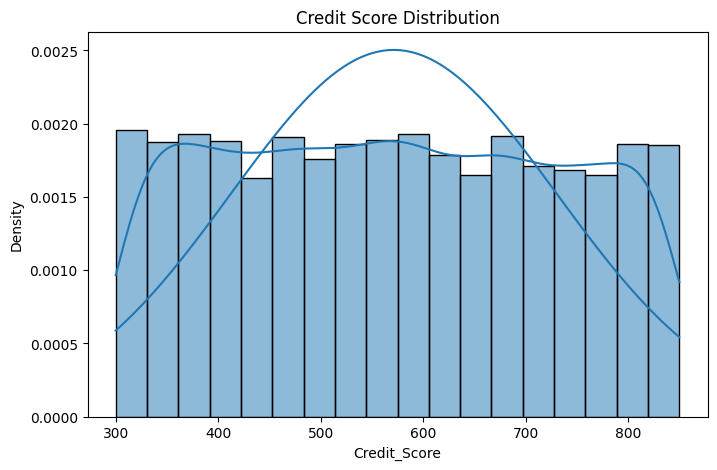

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Credit_Score"],
    kde=True,
    stat="density"
)

mu = df["Credit_Score"].mean()

sigma = df["Credit_Score"].std()

x = np.linspace(
    df["Credit_Score"].min(),
    df["Credit_Score"].max(),
    100
)

plt.plot(
    x,
    stats.norm.pdf(x,mu,sigma)
)

plt.title(
    "Credit Score Distribution"
)

plt.show()

In [27]:
print(
    "Skewness:",
    df["Loan_Amount"].skew()
)

Skewness: -0.02385058545186057


In [28]:
print(
    "Kurtosis:",
    df["Loan_Amount"].kurt()
)

Kurtosis: -1.1786389859461173


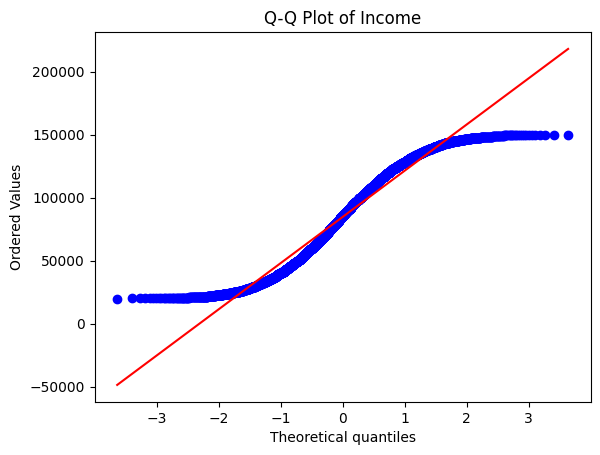

In [29]:
stats.probplot(
    df["Income"],
    dist="norm",
    plot=plt
)

plt.title(
    "Q-Q Plot of Income"
)

plt.show()

In [30]:
vectors = df[
    ["Income","Loan_Amount"]
].head()

print(vectors)

   Income  Loan_Amount
0   57842       127658
1   33900       215912
2  147992       343151
3  100059       156833
4   21881       168637


In [31]:
v1 = vectors.iloc[0].values
v2 = vectors.iloc[1].values

dot_product = np.dot(
    v1,
    v2
)

print(
    "Dot Product:",
    dot_product
)

Dot Product: 29523737896


In [32]:
norm_value = np.linalg.norm(v1)

print(
    "Norm:",
    norm_value
)

Norm: 140150.85418219896


In [33]:
cos_theta = (
    np.dot(v1,v2)
    /
    (
        np.linalg.norm(v1)
        *
        np.linalg.norm(v2)
    )
)

angle = np.degrees(
    np.arccos(cos_theta)
)

print(
    "Angle:",
    angle
)

Angle: 15.452267491227213


FINAL CONCLUSION

The project successfully applied statistical analysis, probability theory, data visualization, and linear algebra techniques to evaluate loan default risk. Income distribution was analyzed using mean, median, and mode, while loan variability was measured using range, variance, and standard deviation. Probability and conditional probability helped quantify default risk. Distribution analysis through histograms, skewness, kurtosis, and Q-Q plots provided deeper understanding of data characteristics. Linear algebra operations such as dot product, vector norm, and angle between vectors demonstrated mathematical relationships among customer financial profiles. The results indicate that customers with lower credit scores and higher loan amounts are more likely to default, making these factors important indicators for credit risk assessment.